In [ ]:
# in a notebook cell
!pip install -q --upgrade transformers datasets
# then restart the runtime (important) or re-import after upgrade

In [ ]:
!pip install --upgrade transformers datasets scikit-learn pandas wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 11.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
   

In [ ]:
pip install --upgrade transformers

In [ ]:
!pip install transformers datasets scikit-learn torch pandas

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
# TODO: Upload the "Mental-Health-Twitter.csv" file to your Colab environment.
df = pd.read_csv("/content/Mental-Health-Twitter.csv")  # Your CSV path
TEXT_COL = "post_text"
LABEL_COL = "label"  # 1 = depressed, 0 = not depressed

# Basic cleaning function
import re, html
def clean_text(s):
    if pd.isna(s): return ""
    s = html.unescape(str(s))
    s = re.sub(r"http\S+", "", s)
    s = re.sub(r"@\w+", "", s)
    s = re.sub(r"#", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = df[TEXT_COL].apply(clean_text)

# ✅ Split dataset (80/10/10)
train_df, temp_df = train_test_split(df[["text_clean", LABEL_COL]], test_size=0.2, stratify=df[LABEL_COL], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df[LABEL_COL], random_state=42)

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

Train: 16000 | Validation: 2000 | Test: 2000


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.rename(columns={"text_clean":"text", LABEL_COL:"label"}))
val_dataset = Dataset.from_pandas(val_df.rename(columns={"text_clean":"text", LABEL_COL:"label"}))
test_dataset = Dataset.from_pandas(test_df.rename(columns={"text_clean":"text", LABEL_COL:"label"}))

In [ ]:
from transformers import DebertaTokenizer, DebertaForSequenceClassification, Trainer, TrainingArguments

model_name = "microsoft/deberta-base"
# Ensure you have torch version 2.6 or newer installed to avoid the ValueError
tokenizer = DebertaTokenizer.from_pretrained(model_name)
model = DebertaForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Tokenize datasets
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

In [ ]:
from transformers import TrainingArguments

# ✅ Define these values explicitly
num_train_epochs = 10
per_device_train_batch_size = 16
gradient_accumulation_steps = 2

# If you haven’t defined your dataset yet, make sure you replace train_dataset with your actual variable
train_size = len(train_dataset)  # <-- ensure train_dataset is loaded
steps_per_epoch = int(train_size / (per_device_train_batch_size * gradient_accumulation_steps))

# ✅ Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=gradient_accumulation_steps,
    eval_strategy="epoch",      # runs evaluation once per epoch
    save_strategy="epoch",      # saves checkpoint once per epoch
    logging_dir='./logs',
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1",  # Set metric for best model
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    report_to=["wandb"],
    fp16=False   # keep False because your GPU threw overflow earlier
)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,          # ✅ Use validation during training
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

## Wandb API = 17cac671cea07c4a6b25762412a99b6d14864d57

In [ ]:
import wandb
import getpass

# Securely ask for your API key
api_key = getpass.getpass("🔑 Enter your W&B API key: ")

# Log in BEFORE wandb.init()
wandb.login(key=api_key)

# Fetch user info safely (no parentheses)
api = wandb.Api()
user = api.viewer

print(f"✅ Logged in as: {user.username}")
print(f"📦 Entity: {user.entity}")

# Initialize a run/project
run = wandb.init(
    project="huggingface",
    name="DeBERTa-Depression",
    config={
        "model": "deberta-base",
        "epochs": 10,
        "batch_size": 16,
        "learning_rate": 2e-5
    }
)

print(f"🔗 Project URL: {run.url}")

🔑 Enter your W&B API key: ··········


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vishnuvainesh25 (vishnuvainesh25-karunya-institute-of-technology-and-sciences) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Logged in as: vishnuvainesh25
📦 Entity: vishnuvainesh25-karunya-institute-of-technology-and-sciences


🔗 Project URL: https://wandb.ai/vishnuvainesh25-karunya-institute-of-technology-and-sciences/huggingface/runs/s8pbahok


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.490800,0.404933,0.792500,0.817743,0.729052,0.931000
2,0.340900,0.361299,0.835000,0.838235,0.822115,0.855000
3,0.221100,0.387187,0.848000,0.852570,0.827684,0.879000
4,0.140800,0.500278,0.846500,0.849878,0.831579,0.869000
5,0.089100,0.682771,0.836000,0.834176,0.843558,0.825000
6,0.052700,0.896739,0.846500,0.849731,0.832215,0.868000
7,0.042100,1.006508,0.852500,0.850935,0.860061,0.842000
8,0.030400,1.128044,0.848500,0.852555,0.830332,0.876000
9,0.021000,1.174869,0.839500,0.836807,0.851086,0.823000
10,0.010000,1.168917,0.844000,0.845084,0.839250,0.851000


TrainOutput(global_step=5000, training_loss=0.1504786184310913, metrics={'train_runtime': 4291.1418, 'train_samples_per_second': 37.286, 'train_steps_per_second': 1.165, 'total_flos': 1.1896101824301312e+16, 'train_loss': 0.1504786184310913, 'epoch': 10.0})

### **1. Label Distribution (Depressed vs Not Depressed)**

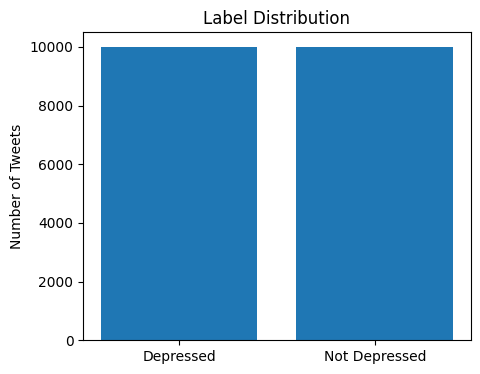

In [ ]:
import matplotlib.pyplot as plt

label_counts = df[LABEL_COL].value_counts()
plt.figure(figsize=(5,4))
plt.bar(label_counts.index.map({0:"Not Depressed", 1:"Depressed"}), label_counts.values)
plt.title("Label Distribution")
plt.ylabel("Number of Tweets")
plt.show()

## **2. Tweet Length Distribution**

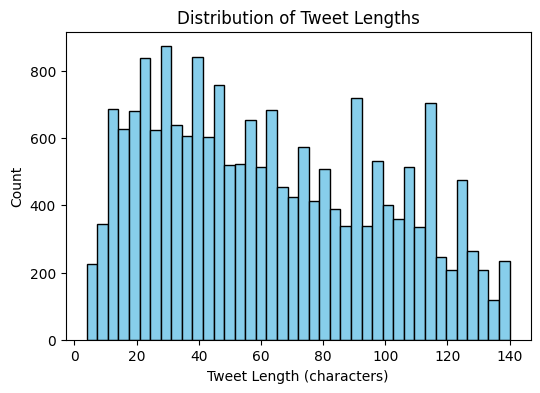

In [ ]:
df["text_length"] = df["text_clean"].apply(len)

plt.figure(figsize=(6,4))
plt.hist(df["text_length"], bins=40, color="skyblue", edgecolor="black")
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (characters)")
plt.ylabel("Count")
plt.show()


## **3. Training and Validation Accuracy/F1 (after model training)**

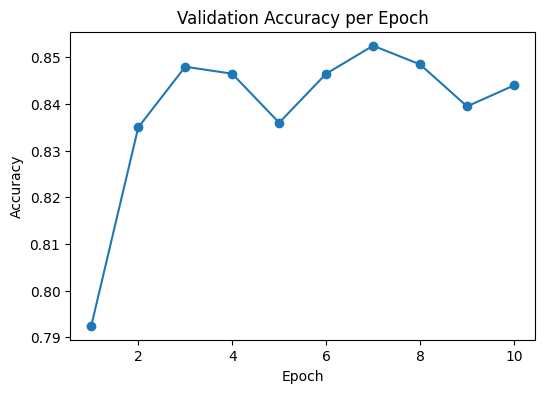

In [ ]:
import matplotlib.pyplot as plt

training_logs = trainer.state.log_history

train_acc = [x["eval_accuracy"] for x in training_logs if "eval_accuracy" in x]
epochs = range(1, len(train_acc)+1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, marker='o')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## **Compute Metrics on Test Set**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch

# Make predictions on test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds = []
all_labels = []

for batch in test_dataset:
    input_ids = batch["input_ids"].unsqueeze(0).to(device)
    attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
    label = batch["label"].item()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    pred = torch.argmax(outputs.logits, dim=1).item()

    all_preds.append(pred)
    all_labels.append(label)

# Classification report
report = classification_report(all_labels, all_preds, target_names=["Not Depressed","Depressed"])
print(report)

               precision    recall  f1-score   support

Not Depressed       0.87      0.79      0.83      1000
    Depressed       0.81      0.88      0.84      1000

     accuracy                           0.83      2000
    macro avg       0.84      0.83      0.83      2000
 weighted avg       0.84      0.83      0.83      2000



## **Confusion Matrix (Graphical)**

✅ Total samples evaluated: 20000


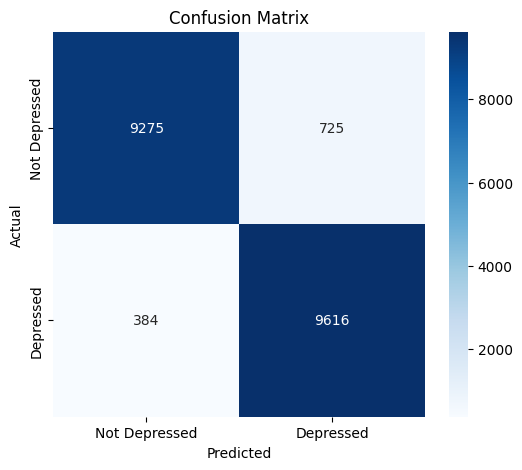

In [ ]:
# ---- Imports ----
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from datasets import concatenate_datasets

# ---- Combine all splits (train + val + test) ----
# (Only if you want to evaluate the entire 20,000 samples)
full_dataset = concatenate_datasets([train_dataset, val_dataset, test_dataset])

# ---- Get predictions from your trained model ----
predictions = trainer.predict(full_dataset)

# ---- Extract predicted labels and actual labels ----
all_preds = np.argmax(predictions.predictions, axis=1)
all_labels = predictions.label_ids

print("✅ Total samples evaluated:", len(all_labels))

# ---- Compute confusion matrix ----
cm = confusion_matrix(all_labels, all_preds)

# ---- Plot confusion matrix (Counts only) ----
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Depressed", "Depressed"],
    yticklabels=["Not Depressed", "Depressed"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch

# Pick a line number safely
line_number = int(input(f"Enter the line number (0 to {len(df)-1}): "))
tweet = df.loc[line_number, TEXT_COL]
cleaned_tweet = clean_text(tweet)

# Tokenize
inputs = tokenizer(
    cleaned_tweet,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

# Move inputs and model to correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_label = torch.argmax(probs, dim=-1).item()

label_map = {0: "not depressed", 1: "depressed"}

# Display results
print("\n📝 Original tweet:", tweet)
print("🧹 Cleaned tweet:", cleaned_tweet)
print(f"🔮 Predicted label: {label_map[pred_label]}")
print(f"📊 Confidence → Not Depressed: {probs[0][0]:.3f}, Depressed: {probs[0][1]:.3f}")


Enter the line number (0 to 19999): 570

📝 Original tweet: #Bipolar not a choice: http://t.co/1oQTrIu7wL
🧹 Cleaned tweet: Bipolar not a choice:
🔮 Predicted label: depressed
📊 Confidence → Not Depressed: 0.000, Depressed: 1.000


In [ ]:
# --- Predict depression from custom input (without modifying dataset) ---

user_input = input("Enter a text to analyze (depressed or not): ")

# Clean and tokenize
cleaned_input = clean_text(user_input)
inputs = tokenizer(cleaned_input, return_tensors="pt", truncation=True, padding=True, max_length=128)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inputs = {k: v.to(device) for k, v in inputs.items()}
model.to(device)

# Predict
with torch.no_grad():
    outputs = model(**inputs)
pred_label = torch.argmax(outputs.logits).item()

# Map and display
label_map = {0: "not depressed", 1: "depressed"}
print("\nOriginal text:", user_input)
print("Cleaned text:", cleaned_input)
print("Predicted label:", label_map[pred_label])

Enter a text to analyze (depressed or not): Bipolar not a choice

Original text: Bipolar not a choice
Cleaned text: Bipolar not a choice
Predicted label: depressed


bearer_token = AAAAAAAAAAAAAAAAAAAAANBL4wEAAAAACvYnMQcGjN1Q272WyqW30%2FE1TWI%3DAw9ZS10tplrEpLrvNXRBmUUjSafV89ov03fm3zybqcUQPNLw4b

In [ ]:
!export TWITTER_BEARER_TOKEN="AAAAAAAAAAAAAAAAAAAAANBL4wEAAAAACvYnMQcGjN1Q272WyqW30%2FE1TWI%3DAw9ZS10tplrEpLrvNXRBmUUjSafV89ov03fm3zybqcUQPNLw4b"

In [ ]:
# Run this in Colab or locally. It will prompt you for the token without echoing it.
import os
import getpass

# Prompt safely (token won't show)
BEARER_TOKEN = getpass.getpass("Enter your TWITTER_BEARER_TOKEN (input hidden): ").strip()
if not BEARER_TOKEN:
    raise SystemExit("No bearer token provided. Exiting.")

# (Optional) store in env for libraries that read it
os.environ["TWITTER_BEARER_TOKEN"] = BEARER_TOKEN

# Continue with tweet fetch + inference...

Enter your TWITTER_BEARER_TOKEN (input hidden): ··········


In [ ]:
# Colab secret read (may raise SecretNotFoundError if not set)
try:
    from google.colab import userdata
    BEARER_TOKEN = userdata.get("TWITTER_BEARER_TOKEN")
except Exception as e:
    # Fallback: ask interactively (safe)
    import getpass
    BEARER_TOKEN = getpass.getpass("Enter TWITTER_BEARER_TOKEN: ").strip()

if not BEARER_TOKEN:
    raise SystemExit("No bearer token available.")

Enter TWITTER_BEARER_TOKEN: ··········
